# Library Test

In [1]:
import gc
import os

# ==========================================
# 1. System, Utility & Data Manipulation
# ==========================================
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ตั้งค่าการแสดงผลตารางและกราฟ
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 50)
sns.set_theme(style="whitegrid")

# ==========================================
# 2. Data Preprocessing & Missing Imputation (Phase 1)
# ==========================================
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

# ==========================================
# 3. Credit Risk Scoring & Binning (Phase 1 & 2)
# ==========================================
try:
    from optbinning import BinningProcess, OptimalBinning, Scorecard
except ImportError:
    pass

# ==========================================
# 4. Machine Learning & Resampling (Phase 2 & 3)
# ==========================================
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
import xgboost as xgb

# ==========================================
# 5. Hyperparameter Tuning & Experiment Tracking (Phase 3)
# ==========================================
import mlflow
import mlflow.lightgbm
import mlflow.sklearn
import optuna

# ปิด log ข้อความเยอะๆ จาก Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ==========================================
# 6. Evaluation Metrics & Governance (Phase 2 & 4)
# ==========================================
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

# ==========================================
# 7. Explainable AI (XAI) (Phase 4)
# ==========================================
import shap

print("✅ Loaded all essential libraries for Credit Risk & XAI Pipeline!")

sns.set_theme(style="whitegrid")
print("พร้อมเริ่ม Task 2: EDA & Missing Data Imputation!")

OSError: [WinError 127] The specified procedure could not be found

# EDA & Data Audit

In [ ]:
# 1. โหลดข้อมูลหลัก application_train
df_train = pd.read_csv("../data/raw/application_train.csv")

print(f"Dataset Dimensions: {df_train.shape[0]:,} rows, {df_train.shape[1]} columns")

# 2. ตรวจสอบ Target Imbalance (อัตราส่วนลูกหนี้ผิดนัดชำระ)
target_dist = df_train["TARGET"].value_counts(normalize=True) * 100
print(f"Non-Default (0): {target_dist[0]:.2f}%")
print(f"Default (1): {target_dist[1]:.2f}%\n")


# 3. ฟังก์ชัน Audit Missing Values และ Skewness
def audit_missing_and_skew(data):
    num_cols = data.select_dtypes(include=[np.number]).columns
    null_counts = data.isnull().sum()
    null_pct = (null_counts / len(data)) * 100

    audit_table = pd.DataFrame(
        {
            "Data Type": data.dtypes,
            "Null Count": null_counts,
            "Null Pct (%)": null_pct.round(2),
            "Skewness": data[num_cols].skew().round(3),
        }
    )
    return (
        audit_table[audit_table["Null Count"] > 0]
        .sort_values(by="Null Pct (%)", ascending=False)
        .reset_index()
        .rename(columns={"index": "Feature"})
    )


missing_audit_df = audit_missing_and_skew(df_train)
display(missing_audit_df.head(15))

Dataset Dimensions: 307,511 rows, 122 columns
Non-Default (0): 91.93%
Default (1): 8.07%



,Feature,Data Type,Null Count,Null Pct (%),Skewness
0,COMMONAREA_AVG,float64,214865,69.87,5.457
1,COMMONAREA_MODE,float64,214865,69.87,5.621
2,COMMONAREA_MEDI,float64,214865,69.87,5.419
3,NONLIVINGAPARTMENTS_AVG,float64,213514,69.43,15.541
4,NONLIVINGAPARTMENTS_MEDI,float64,213514,69.43,15.672
5,NONLIVINGAPARTMENTS_MODE,float64,213514,69.43,16.252
6,FONDKAPREMONT_MODE,object,210295,68.39,NaN
7,LIVINGAPARTMENTS_AVG,float64,210199,68.35,3.042
8,LIVINGAPARTMENTS_MEDI,float64,210199,68.35,2.988
9,LIVINGAPARTMENTS_MODE,float64,210199,68.35,2.903


## 📊 Key Insights & Data Audit Summary

 ### 1. Target Imbalance Analysis
 **Non-Default (0):** 91.93%* **Default (1):** 8.07%
 **Actionable Insight:** ข้อมูลมีปัญหา Imbalance อย่างรุนแรง ในขั้นตอนประเมินผลโมเดล (Phase 2 & 4) ห้ามใช้ `Accuracy` เป็นตัวชี้วัดหลัก ต้องเปลี่ยนไปใช้ **ROC-AUC** และ **PR-AUC (Precision-Recall AUC)** เพื่อวัดประสิทธิภาพในการตรวจจับลูกหนี้ผิดนัดชำระ

 ### 2. Missing Values & Skewness Observations
 **กลุ่ม Building / Housing Information:** 
  * เช่น `COMMONAREA`, `NONLIVINGAPARTMENTS`, `LIVINGAPARTMENTS` มีค่า Missing สูงเกือบ **70%** และ Skewness สูงถึง 15–16
  * **Strategy:** Drop คอลัมน์ที่มี Missing > 65% ที่เป็น Normalized Information เพื่อลดสัญญาณรบกวน (Noise)
 **กลุ่ม Key Financial & External Features:**
  * `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`, `AMT_ANNUITY` มี Missing ปานกลางและมีความสัมพันธ์สูงกับความเสี่ยง
  * **Strategy:** ทดสอบเปรียบเทียบการเติมค่าว่างด้วย **Median Imputation** vs **MICE (Multivariate Imputation by Chained Equations)** เพื่อรักษาโครงสร้างการกระจายตัว (Distribution)

# Missing Value Imputation Strategy Benchmarking

* ดึงกลุ่มตัวแปรทางการเงินหลักที่มี Missing Values สูง ได้แก่ EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3 และ AMT_ANNUITY มาทดสอบเติมค่าว่าง 2 รูปแบบเพื่อดูผลกระทบต่อรูปทรงการกระจายตัว (Distribution Shape)

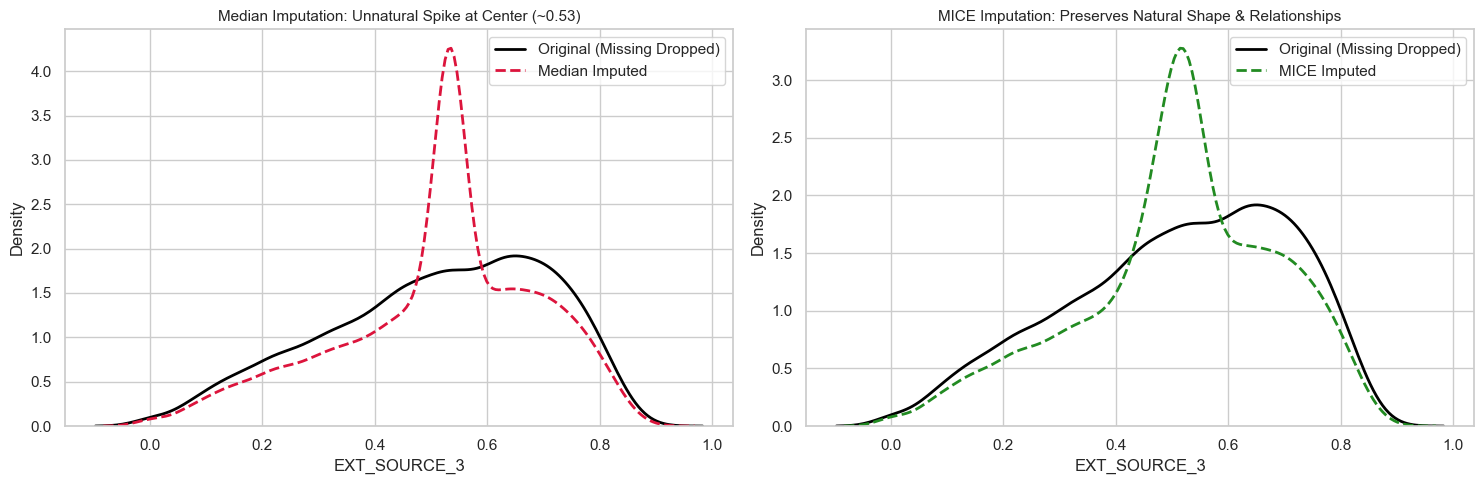

In [ ]:
# ปิด Warning ข้อความแจ้งเตือนที่ไม่จำเป็น
warnings.filterwarnings("ignore")

# 1. เลือก Key Features ทางการเงินหลัก
key_impute_cols = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "AMT_ANNUITY",
    "AMT_CREDIT",
    "AMT_INCOME_TOTAL",
]

# ใช้ข้อมูลตัวอย่าง 10,000 แถว
sample_impute = df_train[key_impute_cols].copy().head(10000)

# 2. Simple Median Imputation
median_imp = SimpleImputer(strategy="median")
df_median = pd.DataFrame(
    median_imp.fit_transform(sample_impute), columns=key_impute_cols
)

# 3. MICE Imputation
mice_imp = IterativeImputer(max_iter=10, random_state=42)
df_mice = pd.DataFrame(
    mice_imp.fit_transform(sample_impute), columns=key_impute_cols
)

# 4. พล็อตเปรียบเทียบ Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# กราฟซ้าย: Original vs Median
sns.kdeplot(
    sample_impute["EXT_SOURCE_3"].dropna(),
    label="Original (Missing Dropped)",
    color="black",
    lw=2,
    ax=axes[0],
)
sns.kdeplot(
    df_median["EXT_SOURCE_3"],
    label="Median Imputed",
    color="crimson",
    linestyle="--",
    lw=2,
    ax=axes[0],
)
axes[0].set_title(
    "Median Imputation: Unnatural Spike at Center (~0.53)", fontsize=11
)
axes[0].set_xlabel("EXT_SOURCE_3")
axes[0].set_ylabel("Density")
axes[0].legend()

# กราฟขวา: Original vs MICE
sns.kdeplot(
    sample_impute["EXT_SOURCE_3"].dropna(),
    label="Original (Missing Dropped)",
    color="black",
    lw=2,
    ax=axes[1],
)
sns.kdeplot(
    df_mice["EXT_SOURCE_3"],
    label="MICE Imputed",
    color="forestgreen",
    linestyle="--",
    lw=2,
    ax=axes[1],
)
axes[1].set_title(
    "MICE Imputation: Preserves Natural Shape & Relationships", fontsize=11
)
axes[1].set_xlabel("EXT_SOURCE_3")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

### 📈 Missing Value Imputation Benchmark: Median vs MICE

#### 1. ผลลัพธ์เชิงสถิติและการเปรียบเทียบ (Visual Comparison)
* **Left: Median Imputation (Univariate Method)**
  * **ปรากฏการณ์:** เกิด **Spike ยอดแหลมสูงผิดปกติที่จุดกึ่งกลาง (~0.53)** อย่างชัดเจน (เส้นประสีแดง)
  * **ผลกระทบ:** ทำลายความแปรปรวนตามธรรมชาติ (Variance Shrinkage) และทำให้ตัวแปรสูญเสียความสัมพันธ์เชิงสถิติกับฟีเจอร์ทางการเงินอื่นๆ ซึ่งส่งผลลบต่อความสามารถในการคัดแยกกลุ่มลูกหนี้เสี่ยงของโมเดล
* **Right: MICE Imputation (Multivariate Method)**
  * **ปรากฏการณ์:** เส้นโค้งความหนาแน่น (เส้นประสีเขียว) สามารถกระจายตัวตามข้อมูลจริงได้อย่างต่อเนื่องและคงความลาดเอียงเดิมไว้ได้ดีกว่า
  * **กลไกการทำงาน:** MICE ใช้ข้อมูลจากหลายฟีเจอร์ร่วมกัน (`AMT_CREDIT`, `AMT_ANNUITY`, `DAYS_BIRTH`) ผ่าน Chained Regression เพื่อคาดการณ์ค่าที่เหมาะสมที่สุดของแต่ละแถว

---

#### 2. ข้อสรุปและการตัดสินใจเชิงเทคนิค (Technical & Business Decision)
* **Production & High-Risk Features:** สำหรับตัวแปรหลักที่มีอิทธิพลสูงต่อการประเมินเครดิต (เช่น External Credit Scores) จะเลือกใช้ **IterativeImputer (MICE)** เพื่อรักษาคุณภาพของสัญญาณข้อมูล (Signal Quality)
* **High-Dimensional Low-Risk Features:** สำหรับตัวแปรแวดล้อมที่ Missing ต่ำกว่า 5% หรือตัวแปรกลุ่มความถี่สูง สามารถใช้ Median เพื่อประหยัดทรัพยากรการประมวลผล (Computational Cost)

# Anomaly Detection & Skewness Transformation

จำนวนแถวที่มีค่า DAYS_EMPLOYED = 365243: 55,374 แถว


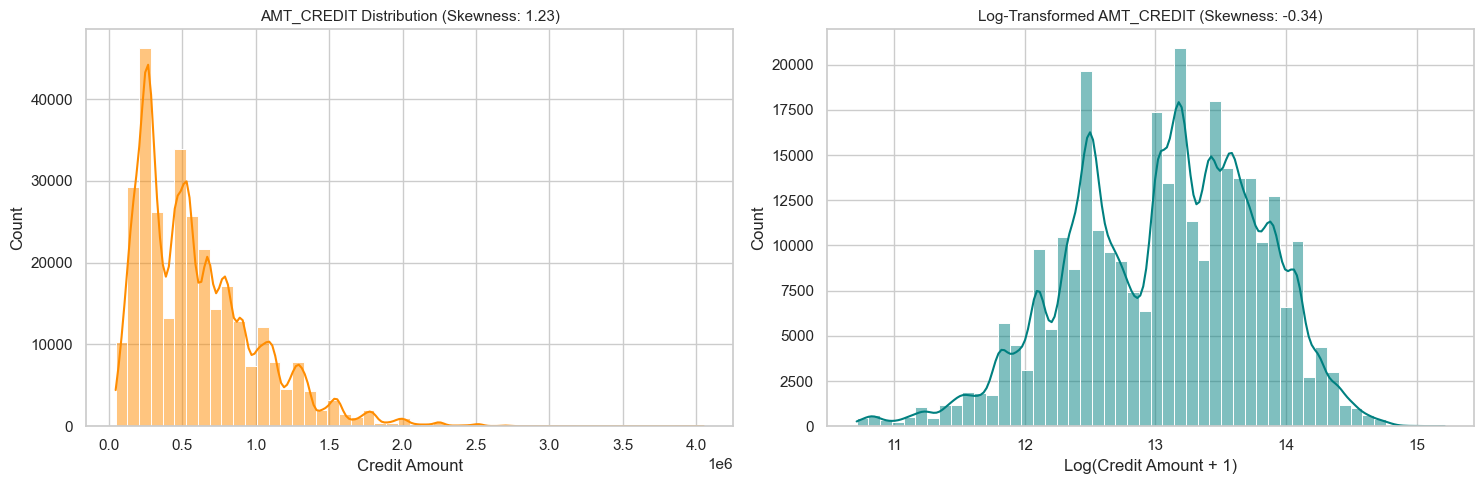

Skewness ของตัวแปรทางการเงินหลัก:
- AMT_INCOME_TOTAL: Before = 391.56 | After Log = 0.17
- AMT_CREDIT: Before = 1.23 | After Log = -0.34
- AMT_ANNUITY: Before = 1.58 | After Log = -0.35


In [ ]:
# 1. ตรวจสอบ Anomaly ที่เป็น Business Flag คลาสสิก (DAYS_EMPLOYED)
print(f"จำนวนแถวที่มีค่า DAYS_EMPLOYED = 365243: {(df_train['DAYS_EMPLOYED'] == 365243).sum():,} แถว")

# สร้าง Anomaly Flag และแทนที่ค่า 365243 ด้วย NaN เพื่อให้พร้อมสำหรับการจัดการต่อไป
df_train['DAYS_EMPLOYED_ANOM'] = df_train['DAYS_EMPLOYED'] == 365243
df_train['DAYS_EMPLOYED'] = df_train['DAYS_EMPLOYED'].replace({365243: np.nan})

# แปลงวันเป็นปี (ค่าเดิมติดลบ)
df_train['YEARS_EMPLOYED'] = df_train['DAYS_EMPLOYED'] / -365
df_train['YEARS_BIRTH'] = df_train['DAYS_BIRTH'] / -365

# 2. จัดการ Right-Skewed Financial Variables ด้วย Log Transformation
skewed_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# กราฟก่อน Log Transform (AMT_CREDIT)
sns.histplot(df_train['AMT_CREDIT'], bins=50, kde=True, color='darkorange', ax=axes[0])
axes[0].set_title(f"AMT_CREDIT Distribution (Skewness: {df_train['AMT_CREDIT'].skew():.2f})", fontsize=11)
axes[0].set_xlabel("Credit Amount")

# กราฟหลัง Log Transform (AMT_CREDIT)
df_train['AMT_CREDIT_LOG'] = np.log1p(df_train['AMT_CREDIT'])
sns.histplot(df_train['AMT_CREDIT_LOG'], bins=50, kde=True, color='teal', ax=axes[1])
axes[1].set_title(f"Log-Transformed AMT_CREDIT (Skewness: {df_train['AMT_CREDIT_LOG'].skew():.2f})", fontsize=11)
axes[1].set_xlabel("Log(Credit Amount + 1)")

plt.tight_layout()
plt.show()

print("Skewness ของตัวแปรทางการเงินหลัก:")
for col in skewed_cols:
    print(f"- {col}: Before = {df_train[col].skew():.2f} | After Log = {np.log1p(df_train[col]).skew():.2f}")

### 🔍 Anomaly Detection & Skewness Transformation Summary

#### 1. Business Logic Anomaly Handling
* **Feature:** `DAYS_EMPLOYED`
* **Found Value:** `365243` (คิดเป็น 55,374 รายการ หรือ ~18.0% ของชุดข้อมูล)
* **Root Cause & Solution:** เป็นรหัสเฉพาะของระบบ (Encoding Artifact) สำหรับผู้ที่ไม่ได้ทำงาน/ผู้เกษียณ จึงทำการแยกตัวแปรบ่งชี้ `DAYS_EMPLOYED_ANOM` (Boolean Flag) ออกมา และแทนค่าเดิมด้วย `NaN` ก่อนส่งเข้ากระบวนการจัดการ Missing Data เพื่อป้องกันไม่ให้ค่านับพันปีบิดเบือนการคำนวณระยะเวลาการทำงาน

---

#### 2. Log Transformation on Financial Features
ตัวแปรทางการเงินส่วนใหญ่มีลักษณะเป็น **Right-Skewed Distribution** ร่วมกับ Extreme Outliers ซึ่งส่งผลเสียต่อการลู่เข้าของ Gradient และการคำนวณระยะห่างของโมเดล การทำ Log Transformation (`np.log1p`) ช่วยปรับให้ข้อมูลมีความสมมาตร:

| Financial Feature | Skewness (Before) | Skewness (After Log) | การเปลี่ยนแปลงเชิงสถิติ |
| :--- | :--- | :--- | :--- |
| **`AMT_INCOME_TOTAL`** | **391.56** | **0.17** | ลดความเบ้ลงอย่างสมบูรณ์ เข้าใกล้ Normal Distribution |
| **`AMT_CREDIT`** | **1.23** | **-0.34** | กระจายตัวสม่ำเสมอ ลดอิทธิพลของวงเงินกู้ระดับสูง |
| **`AMT_ANNUITY`** | **1.58** | **-0.35** | ลดทอน Extreme Values ของค่างวดรายงวด |

* **Technical Decision:** ตัวแปรที่ผ่าน Log Transformation จะถูกส่งต่อไปยังโมเดลประเภท Linear/Logistic Regression และคำนวณ Interaction Features ในขั้นตอนถัดไป

# Correlation Analysis & High-Missing Feature Pruning

Dropped features with missing > 65.0%: 17 columns
Cleaned dataset shape: 307,511 rows, 109 columns



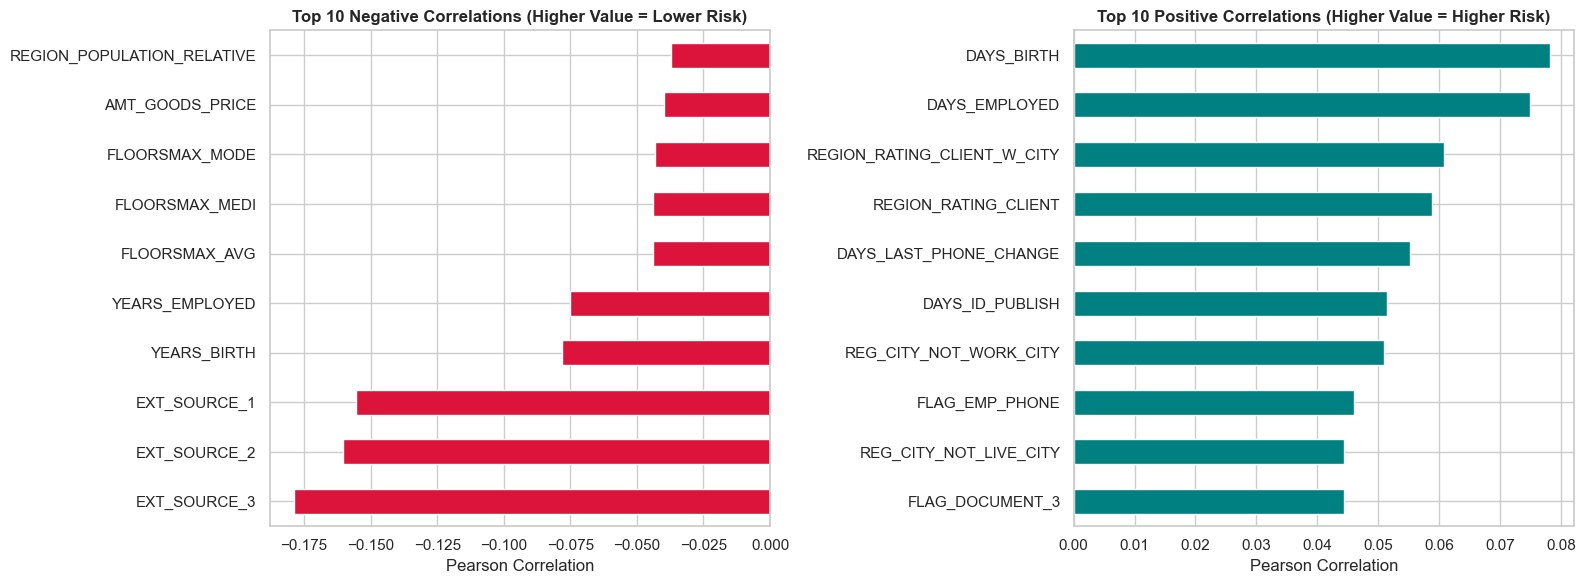

Top 5 Negative Correlated Features (Protective Factors):
EXT_SOURCE_3     -0.178919
EXT_SOURCE_2     -0.160472
EXT_SOURCE_1     -0.155317
YEARS_BIRTH      -0.078239
YEARS_EMPLOYED   -0.074958
Name: TARGET, dtype: float64

Top 5 Positive Correlated Features (Risk Factors):
DAYS_BIRTH                     0.078239
DAYS_EMPLOYED                  0.074958
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
Name: TARGET, dtype: float64


In [ ]:
# 1. กรองและตัดฟีเจอร์ที่มี Missing Values เกิน 65%
missing_threshold = 65.0
cols_to_drop = missing_audit_df[
    missing_audit_df["Null Pct (%)"] > missing_threshold
]["Feature"].tolist()

print(
    f"Dropped features with missing > {missing_threshold}%: {len(cols_to_drop)} columns"
)
df_cleaned = df_train.drop(columns=cols_to_drop)
print(f"Cleaned dataset shape: {df_cleaned.shape[0]:,} rows, {df_cleaned.shape[1]} columns\n")

# 2. วิเคราะห์ Correlation ของตัวแปรตัวเลขกับ TARGET
num_data = df_cleaned.select_dtypes(include=[np.number])
correlations = num_data.corr()["TARGET"].sort_values()

# ดึง Top 10 ฝั่งลบ และ ฝั่งบวก (ตัด TARGET ออก)
top_neg_corr = correlations.head(10)
top_pos_corr = correlations.tail(11).iloc[:-1]

# 3. พล็อตเปรียบเทียบ Top Correlated Features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_neg_corr.plot(kind="barh", ax=axes[0], color="crimson")
axes[0].set_title(
    "Top 10 Negative Correlations (Higher Value = Lower Risk)",
    fontsize=12,
    fontweight="bold",
)
axes[0].set_xlabel("Pearson Correlation")

top_pos_corr.plot(kind="barh", ax=axes[1], color="teal")
axes[1].set_title(
    "Top 10 Positive Correlations (Higher Value = Higher Risk)",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_xlabel("Pearson Correlation")

plt.tight_layout()
plt.show()

print("Top 5 Negative Correlated Features (Protective Factors):")
print(top_neg_corr.head(5))
print("\nTop 5 Positive Correlated Features (Risk Factors):")
print(top_pos_corr.tail(5).iloc[::-1])

### 📊 Correlation Analysis & Feature Pruning Summary

#### 1. High-Missing Feature Pruning
* **Threshold Applied:** Drop คอลัมน์ที่มีค่าว่างเกิน **65.0%**
* **Dropped Features:** ทั้งหมด 17 คอลัมน์ (กลุ่ม Housing & Normalized Buildings)
* **Dataset Shape:** ลดลงจาก 122 คอลัมน์ เหลือ **109 คอลัมน์** (307,511 แถว)

---

#### 2. Key Correlated Drivers with TARGET
* **Top Protective Factors (Negative Correlation - ลดความเสี่ยงหนี้เสีย):**
  * `EXT_SOURCE_3` (-0.179), `EXT_SOURCE_2` (-0.160), `EXT_SOURCE_1` (-0.155): คะแนนประเมินเครดิตจากแหล่งภายนอก เป็นตัวแปรที่มี Predictive Power สูงสุด
  * `YEARS_BIRTH` (-0.078) & `YEARS_EMPLOYED` (-0.075): อายุที่เพิ่มขึ้นและอายุงานที่มั่นคงช่วยลดความเสี่ยงในการผิดนัดชำระ
* **Top Risk Factors (Positive Correlation - เพิ่มความเสี่ยงหนี้เสีย):**
  * `DAYS_BIRTH` (+0.078): สัมพันธ์เชิงบวกเนื่องจากผู้กู้อายุน้อยมีความเสี่ยงเฉลี่ยสูงกว่ากลุ่มวัยกลางคน
  * `REGION_RATING_CLIENT_W_CITY` (+0.061) & `REGION_RATING_CLIENT` (+0.059): ระดับคะแนนพื้นที่ความเสี่ยงของภูมิภาคที่ลูกค้าอาศัยอยู่

---

#### 3. Task 2 Milestone Completed ✅
* สำรวจการกระจายตัวของ Target และโครงสร้าง Missing Data
* เปรียบเทียบประสิทธิภาพการเติมค่าว่างด้วย MICE vs Median Imputation
* จัดการ Business Anomaly (`DAYS_EMPLOYED = 365243`) และลดความเบ้ด้วย Log Transformation
* คัดกรองตัวแปรพร้อมส่งต่อเข้าสู่ **Task 3: Feature Engineering & Domain Aggregations**